<a href="https://colab.research.google.com/github/tony-div/data-computation-project/blob/main/data_computation_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
from sklearn.datasets import fetch_covtype
from scipy.stats import zscore
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load the dataset
covtype = fetch_covtype(as_frame=True)

# Features and target
X = covtype.data
y = covtype.target


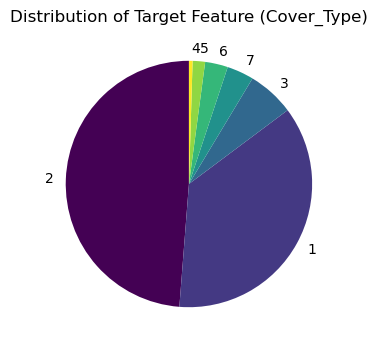

In [3]:
import matplotlib.pyplot as plt

# Count the occurrences of each class in the target feature
target_counts = y.value_counts()

# Plot the pie chart
plt.figure(figsize=(4, 4))
target_counts.plot.pie(startangle=90, cmap='viridis')
plt.title('Distribution of Target Feature (Cover_Type)')
plt.ylabel('')  # Remove the y-label for better visualization
plt.show()

not all cover types has equal number of records which can be a problem while trying to make a svm

In [6]:
X.dtypes

Elevation                             float64
Aspect                                float64
Slope                                 float64
Horizontal_Distance_To_Hydrology      float64
Vertical_Distance_To_Hydrology        float64
Horizontal_Distance_To_Roadways       float64
Hillshade_9am                         float64
Hillshade_Noon                        float64
Hillshade_3pm                         float64
Horizontal_Distance_To_Fire_Points    float64
Wilderness_Area_0                     float64
Wilderness_Area_1                     float64
Wilderness_Area_2                     float64
Wilderness_Area_3                     float64
Soil_Type_0                           float64
Soil_Type_1                           float64
Soil_Type_2                           float64
Soil_Type_3                           float64
Soil_Type_4                           float64
Soil_Type_5                           float64
Soil_Type_6                           float64
Soil_Type_7                       

all features are numeric so we can easily make a correlation matrix

In [25]:
X.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_30,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2785.0,155.0,18.0,242.0,118.0,3090.0,238.0,238.0,122.0,6211.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
X.describe().round(2)

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_30,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39
count,581012.00,581012.00,581012.00,581012.00,581012.00,581012.00,581012.00,581012.00,581012.00,581012.00,...,581012.00,581012.00,581012.00,581012.00,581012.00,581012.00,581012.00,581012.00,581012.00,581012.00
mean,2959.37,155.66,14.10,269.43,46.42,2350.15,212.15,223.32,142.53,1980.29,...,0.04,0.09,0.08,0.00,0.00,0.00,0.00,0.03,0.02,0.02
std,279.98,111.91,7.49,212.55,58.30,1559.25,26.77,19.77,38.27,1324.20,...,0.21,0.29,0.27,0.05,0.06,0.01,0.02,0.16,0.15,0.12
min,1859.00,0.00,0.00,0.00,-173.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2809.00,58.00,9.00,108.00,7.00,1106.00,198.00,213.00,119.00,1024.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,2996.00,127.00,13.00,218.00,30.00,1997.00,218.00,226.00,143.00,1710.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,3163.00,260.00,18.00,384.00,69.00,3328.00,231.00,237.00,168.00,2550.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
max,3858.00,360.00,66.00,1397.00,601.00,7117.00,254.00,254.00,254.00,7173.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


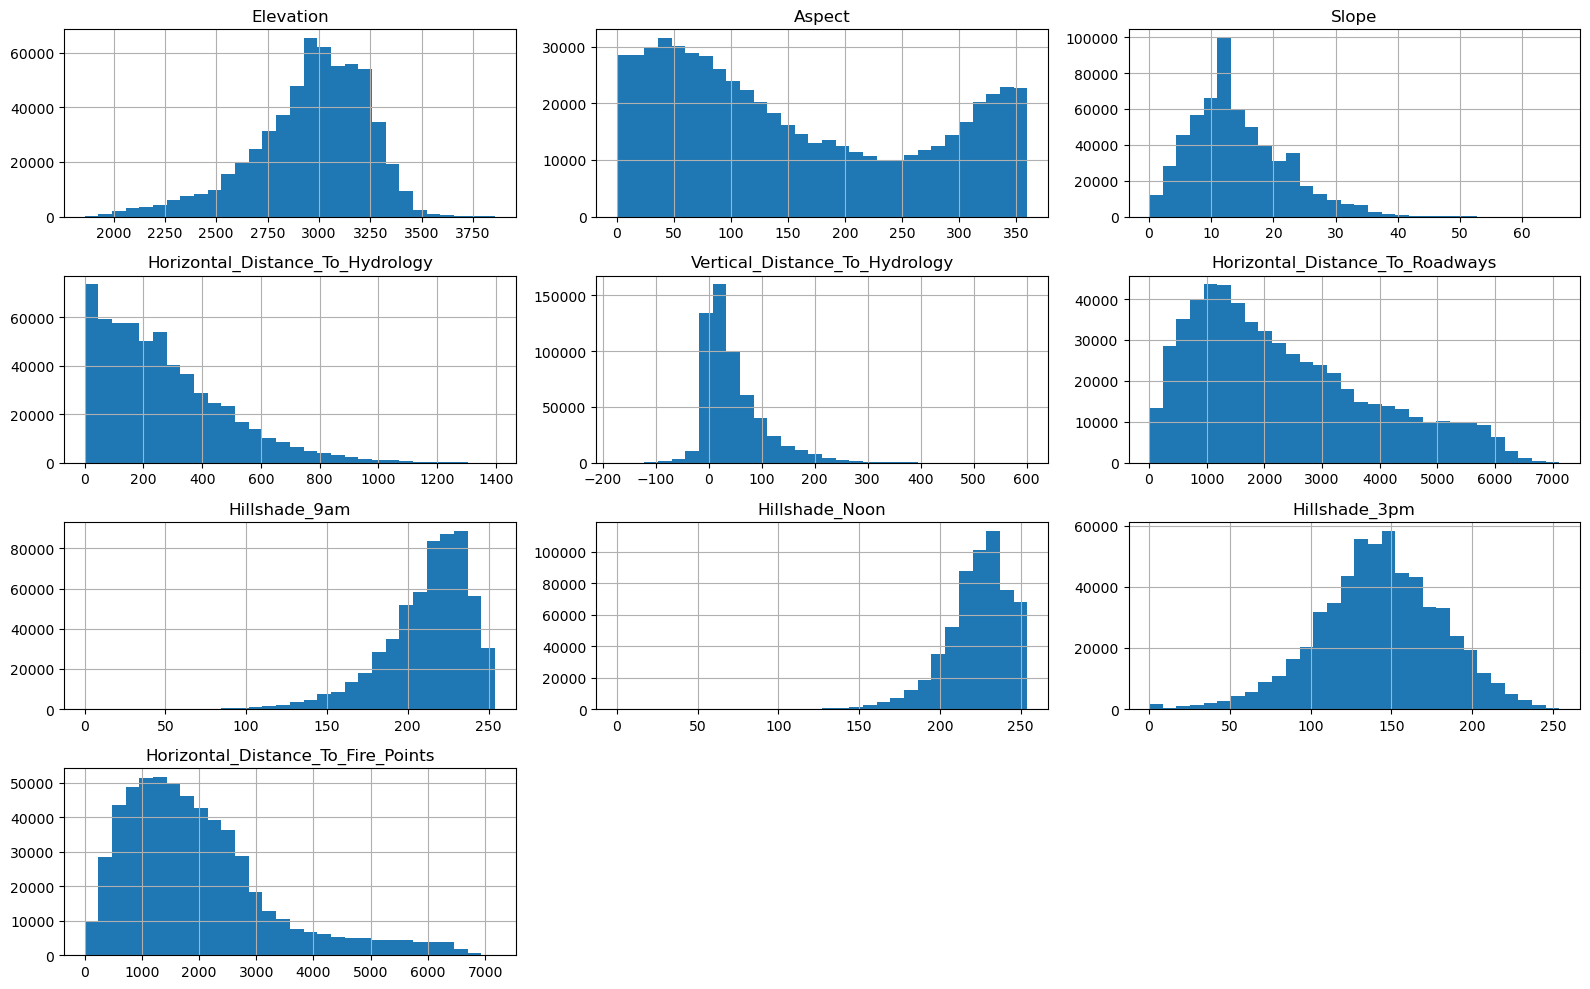

In [ ]:
numerical = X.select_dtypes(include='number').columns[:10]  # select relevant numeric features
X[numerical].hist(figsize=(16, 10), bins=30)
plt.tight_layout()

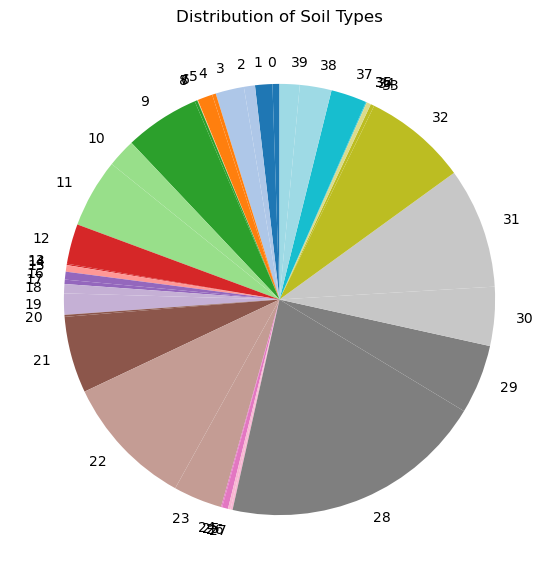

In [43]:
# Count occurrences of each soil type
soil_type_counts = X.filter(like='Soil_Type').sum()

# Count occurrences of each wilderness area
wilderness_area_counts = X.filter(like='Wilderness_Area').sum()

# Modify labels for better readability
soil_type_counts.index = soil_type_counts.index.str.replace('Soil_Type_', '')
wilderness_area_counts.index = wilderness_area_counts.index.str.replace('Wilderness_Area_', '')

# Plot pie chart for soil types
plt.figure(figsize=(7, 7))
soil_type_counts.plot.pie(startangle=90, cmap='tab20', pctdistance=0.85)
plt.title('Distribution of Soil Types')
plt.ylabel('')  # Remove y-label for better visualization

plt.show()

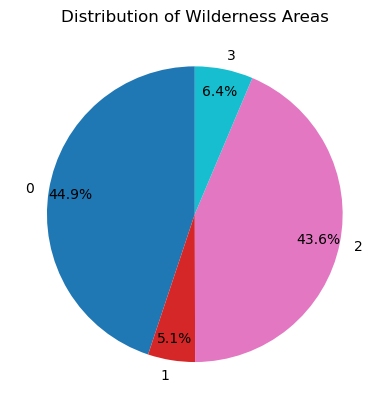

In [39]:
wilderness_area_counts.plot.pie(startangle=90, cmap='tab10', autopct='%1.1f%%', pctdistance=0.85)
plt.title('Distribution of Wilderness Areas')
plt.ylabel('')  # Remove y-label for better visualization
plt.show()

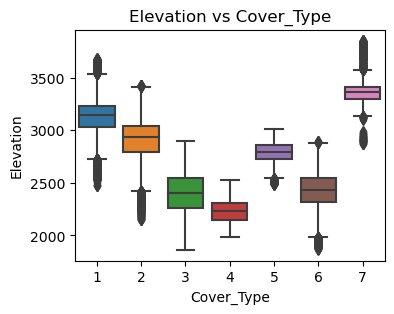

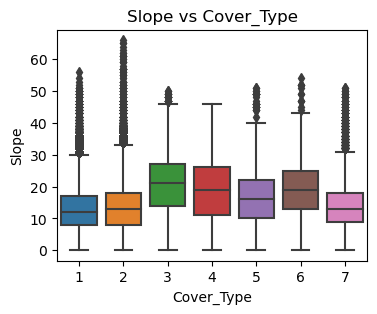

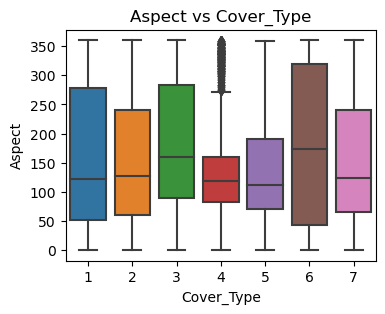

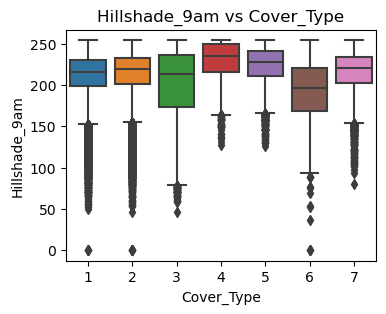

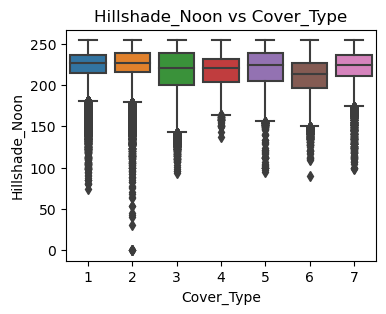

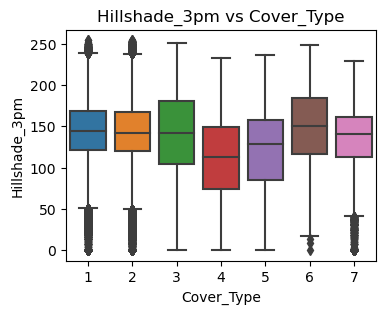

In [45]:
# Create a DataFrame combining features and target
df = X.copy()
df['Cover_Type'] = y

# List of numerical features to plot
features_to_plot = ['Elevation', 'Slope', 'Aspect', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm']

# Generate boxplots for each feature
for feature in features_to_plot:
    plt.figure(figsize=(4, 3))
    sns.boxplot(x='Cover_Type', y=feature, data=df)
    plt.title(f'{feature} vs Cover_Type')
    plt.show()

In [35]:
# Compute the correlation matrix
correlation_matrix = X.corr()

In [16]:
# Unstack the correlation matrix and reset the index
correlation_unstacked = correlation_matrix.unstack().reset_index()

# Rename columns for clarity
correlation_unstacked.columns = ['Feature_1', 'Feature_2', 'Correlation']

# Filter out self-correlations (where Feature_1 == Feature_2)
correlation_unstacked = correlation_unstacked[correlation_unstacked['Feature_1'] != correlation_unstacked['Feature_2']]

# Sort by absolute correlation values in descending order
sorted_correlation = correlation_unstacked.reindex(
    correlation_unstacked['Correlation'].abs().sort_values(ascending=False).index
)

# Print the sorted correlation records
sorted_correlation[sorted_correlation['Correlation'] > 0.5]

,Feature_1,Feature_2,Correlation
433,Hillshade_3pm,Aspect,0.646944
62,Aspect,Hillshade_3pm,0.646944
166,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,0.606236
219,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Hydrology,0.606236
386,Hillshade_Noon,Hillshade_3pm,0.594274
439,Hillshade_3pm,Hillshade_Noon,0.594274
2278,Soil_Type_28,Wilderness_Area_0,0.550549
582,Wilderness_Area_0,Soil_Type_28,0.550549


the relationship between horizontal distance to hydrology and vertical distance to hydrology is obvious. wilderness area 0 tends more to have soil type 28. hillshade in a specific time is obviously related to hillshade in other times and the aspect of the hill

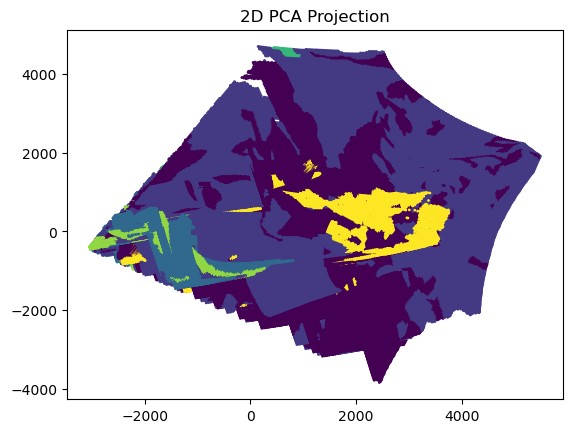

In [23]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', s=1)
plt.title("2D PCA Projection")
plt.show()


In [ ]:
X.isnull().sum()[X.isnull().sum() > 0]

Series([], dtype: int64)

no missing values

In [4]:
duplicates = X.duplicated()
print("Number of duplicates:", duplicates.sum())

Number of duplicates: 0


In [9]:
z_scores = X.apply(zscore)

# Mark rows with any z-score > 3 (common threshold)
outliers = (z_scores.abs() > 3).any(axis=1)
print("Outlier rows:", outliers.sum())


Outlier rows: 472302


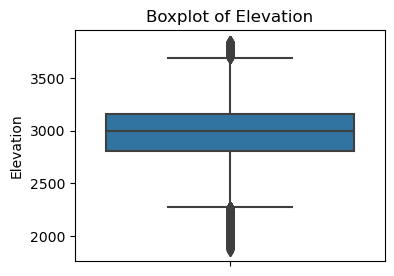

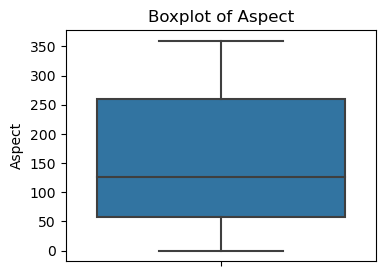

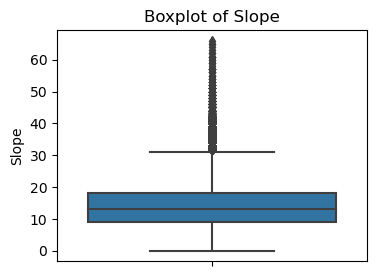

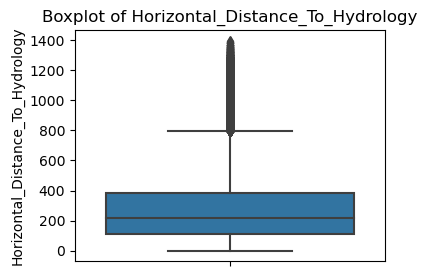

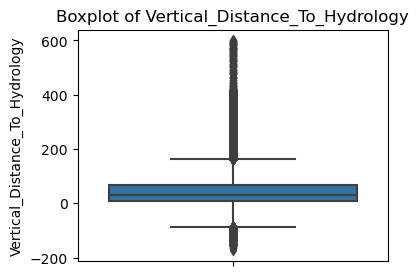

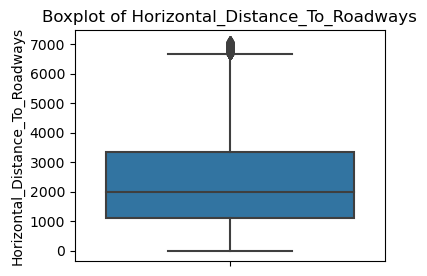

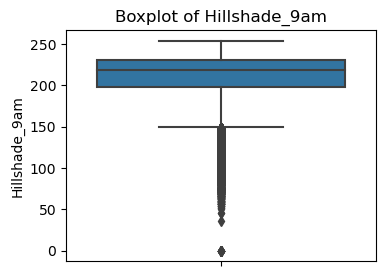

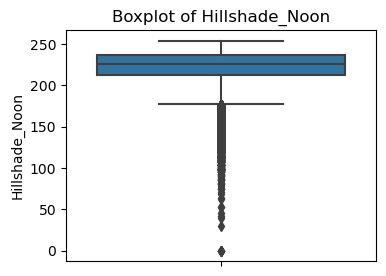

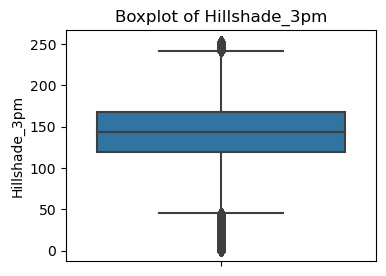

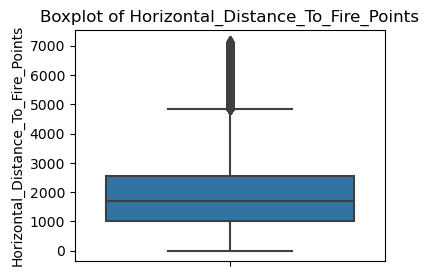

In [13]:
# Select the first 10 features
features_to_plot = X.columns[:10]

# Generate boxplots for each feature
for feature in features_to_plot:
    plt.figure(figsize=(4, 3))
    sns.boxplot(data=X, y=feature)
    plt.title(f'Boxplot of {feature}')
    plt.show()

Although statistical methods have detected outliers in the dataset, these outliers may not necessarily indicate errors or anomalies. Instead, they could be a result of insufficient representation of certain cover types in the dataset.

In [20]:
# Check for invalid Elevation values
invalid_elevation = X[
    (X['Elevation'] < 1800) | 
    (X['Elevation'] > 4000)
    ]
print(f"Invalid Elevation values: {len(invalid_elevation)}")

# Check for invalid Slope values
invalid_slope = X[(X['Slope'] < 0) | (X['Slope'] > 90)]
print(f"Invalid Slope values: {len(invalid_slope)}")

# Check for invalid Aspect values
invalid_aspect = X[(X['Aspect'] < 0) | (X['Aspect'] > 360)]
print(f"Invalid Aspect values: {len(invalid_aspect)}")

# Check for invalid Hillshade values
invalid_hillshade = X[
    (X['Hillshade_9am'] < 0) | (X['Hillshade_9am'] > 255) |
    (X['Hillshade_Noon'] < 0) | (X['Hillshade_Noon'] > 255) |
    (X['Hillshade_3pm'] < 0) | (X['Hillshade_3pm'] > 255)
]
print(f"Invalid Hillshade values: {len(invalid_hillshade)}")

# Check for negative distances
distance_columns = [
    'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways', 'Horizontal_Distance_To_Fire_Points'
]
invalid_distances = X[(X[distance_columns] < 0).any(axis=1)]
print(f"Invalid Distance values: {len(invalid_distances)}")

Invalid Elevation values: 0
Invalid Slope values: 0
Invalid Aspect values: 0
Invalid Hillshade values: 0
Invalid Distance values: 55143


In [21]:
X[distance_columns].describe()

,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Horizontal_Distance_To_Fire_Points
count,581012.000000,581012.000000,581012.000000,581012.000000
mean,269.428217,46.418855,2350.146611,1980.291226
std,212.549356,58.295232,1559.254870,1324.195210
min,0.000000,-173.000000,0.000000,0.000000
25%,108.000000,7.000000,1106.000000,1024.000000
50%,218.000000,30.000000,1997.000000,1710.000000
75%,384.000000,69.000000,3328.000000,2550.000000
max,1397.000000,601.000000,7117.000000,7173.000000


```markdown
Vertical_Distance_To_Hydrology measures the elevation difference between the observation point (site) and the nearest surface water (like a stream, river, or lake).

Sign Meaning:

Positive: The site is above the water level (e.g., a slope or ridge above a river)

Negative: The site is below the water (e.g., a depression, valley, or floodplain)

Zero: Site is at the same elevation as the water body

In [24]:
X['Soil_Sum'] = X.filter(like='Soil_Type').sum(axis=1)
X['Wilderness_Sum'] = X.filter(like='Wilderness_Area').sum(axis=1)

print("Invalid Soil encodings:", (X['Soil_Sum'] != 1).sum())
print("Invalid Wilderness encodings:", (X['Wilderness_Sum'] != 1).sum())

Invalid Soil encodings: 0
Invalid Wilderness encodings: 0
